The objective of this experiment is to introduce students to classification using Decision Tree algorithms. The aim is to develop and understand how a Decision Tree Classifier can be used to categorize data into multiple classes.The experiment focuses on understanding how the tree structure is formed, how splitting of data occurs using criteria such as Gini index,entropy and how model training and prediction are performed. It also aims to help students develop an understanding of how to visualize decision trees, interpret the structure and evaluate the model using confusion matrix and accuracy score.

# Decision Tree Classifier

#### ON IRIS DATASET

In [1]:
from sklearn import datasets

iris = datasets.load_iris()


In [2]:
features = iris.feature_names
features


['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [3]:
iris.target_names


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
iris_X = iris.data
iris_y = iris.target


In [5]:
from sklearn.model_selection import train_test_split

iris_X_train,iris_X_test,iris_y_train,iris_y_test = train_test_split(iris_X,iris_y,test_size=0.2,random_state=12)


In [6]:
from sklearn.tree import DecisionTreeClassifier
import time

start_dtc = time.perf_counter()
dtc  = DecisionTreeClassifier(random_state=5,max_depth=3,criterion='entropy')
dtc.fit(iris_X_train,iris_y_train)
end_dtc = time.perf_counter()
print("Time taken to train: ",end_dtc-start_dtc)


Time taken to train:  0.0011414000000513624


In [7]:
iris_y_pred = dtc.predict(iris_X_test)


In [8]:
from sklearn.metrics import confusion_matrix,accuracy_score


In [9]:
DTCScore = accuracy_score(iris_y_test,iris_y_pred)
print("Accuracy: " , 100 * DTCScore, "%")


Accuracy:  93.33333333333333 %


In [10]:
confusion_matrix(iris_y_test,iris_y_pred)


array([[12,  0,  0],
       [ 0,  7,  2],
       [ 0,  0,  9]])

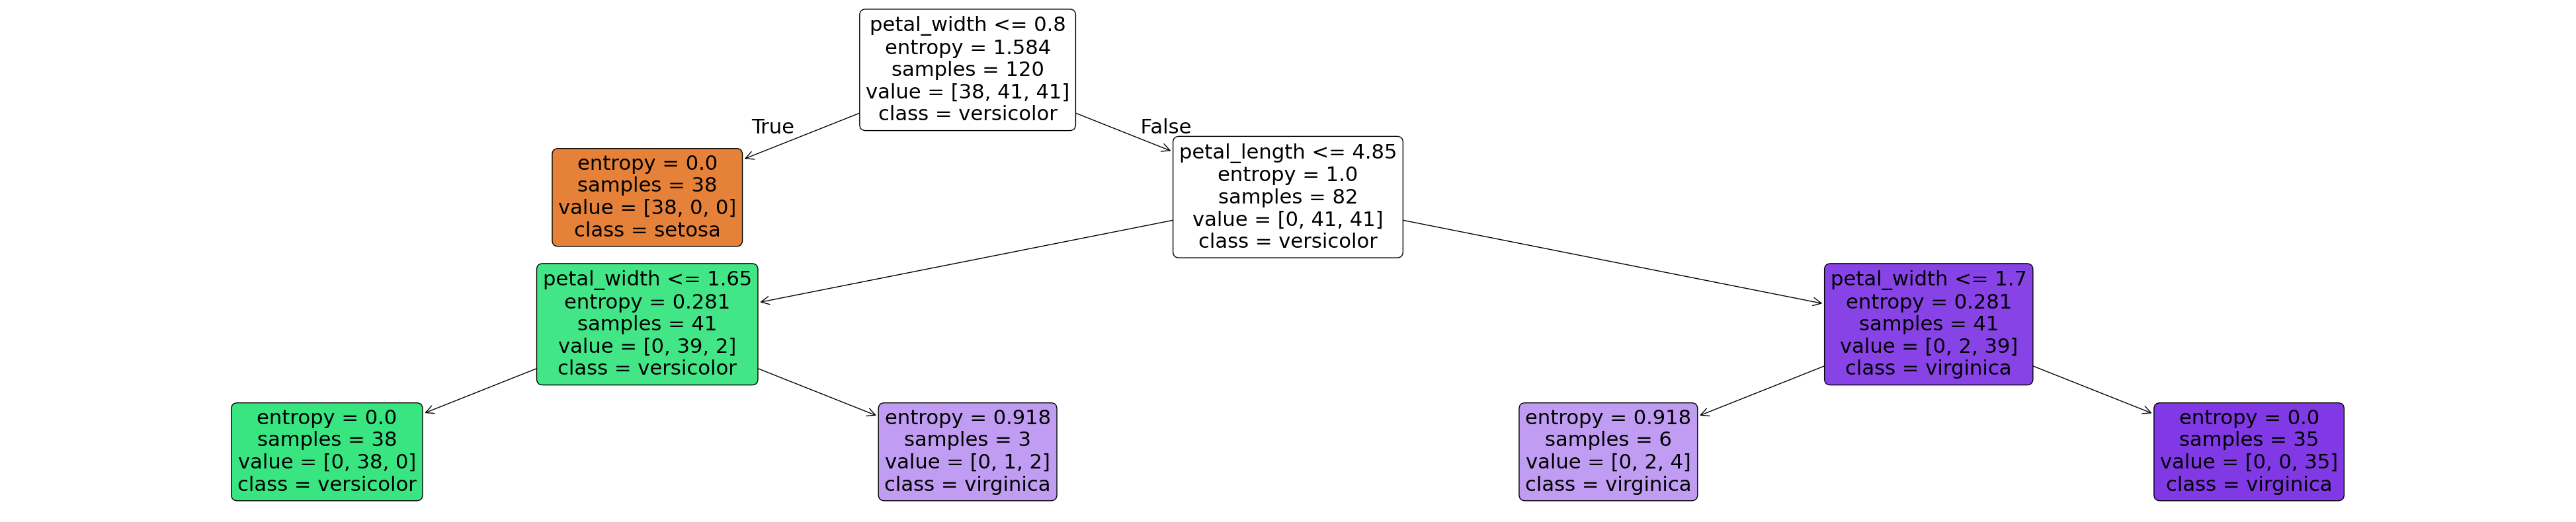

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(50,10))

plot_tree(
    dtc,
    feature_names=["sepal_length","sepal_width","petal_length","petal_width"],
    class_names=["setosa","versicolor","virginica"],
    filled=True,
    rounded=True
)

plt.show()


In [12]:
from sklearn import tree
text_representation = tree.export_text(
    dtc,
    feature_names=["sepal_length","sepal_width","petal_length","petal_width"]
)
print(text_representation)


|--- petal_width <= 0.80
|   |--- class: 0
|--- petal_width >  0.80
|   |--- petal_length <= 4.85
|   |   |--- petal_width <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal_width >  1.65
|   |   |   |--- class: 2
|   |--- petal_length >  4.85
|   |   |--- petal_width <= 1.70
|   |   |   |--- class: 2
|   |   |--- petal_width >  1.70
|   |   |   |--- class: 2



#### ON GEOPOLITICAL DATASET

In [13]:
import pandas as pd

url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/geopolitical_dataset.csv"
geopolitical = pd.read_csv(url)


In [14]:
geopolitical.head()


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [15]:
geopolitical.columns


Index(['military_power_ratio', 'troop_movement', 'nuclear_capability',
       'nuclear_warheads', 'gdp_ratio', 'sanctions_intensity',
       'trade_dependency', 'ideology_distance', 'political_stability',
       'historical_conflict', 'border_distance', 'news_sentiment',
       'nationalism_index', 'leader_aggression', 'target'],
      dtype='str')

In [16]:
features = ['military_power_ratio', 'troop_movement', 'nuclear_capability',
       'nuclear_warheads', 'gdp_ratio', 'sanctions_intensity',
       'trade_dependency', 'ideology_distance', 'political_stability',
       'historical_conflict', 'border_distance', 'news_sentiment',
       'nationalism_index', 'leader_aggression']

X = geopolitical[features].copy()


In [17]:
y = geopolitical.target.copy()


In [18]:
y.nunique()


5

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=12)


In [20]:
start_cf = time.perf_counter()
cf  = DecisionTreeClassifier(random_state=5,max_depth=3,criterion='entropy')
cf.fit(X_train,y_train)
end_cf = time.perf_counter()
print("Time taken to train: ",end_cf-start_cf)


Time taken to train:  0.0062124999985826435


In [21]:
y_pred = cf.predict(X_test)


In [22]:
DTCScore = accuracy_score(y_test,y_pred)
print("Accuracy: " , 100 * DTCScore, "%")


Accuracy:  62.5 %


In [23]:
confusion_matrix(y_test,y_pred)


array([[ 0, 10,  0,  0],
       [ 0, 85,  9,  3],
       [ 0, 29, 19, 13],
       [ 0,  0, 11, 21]])

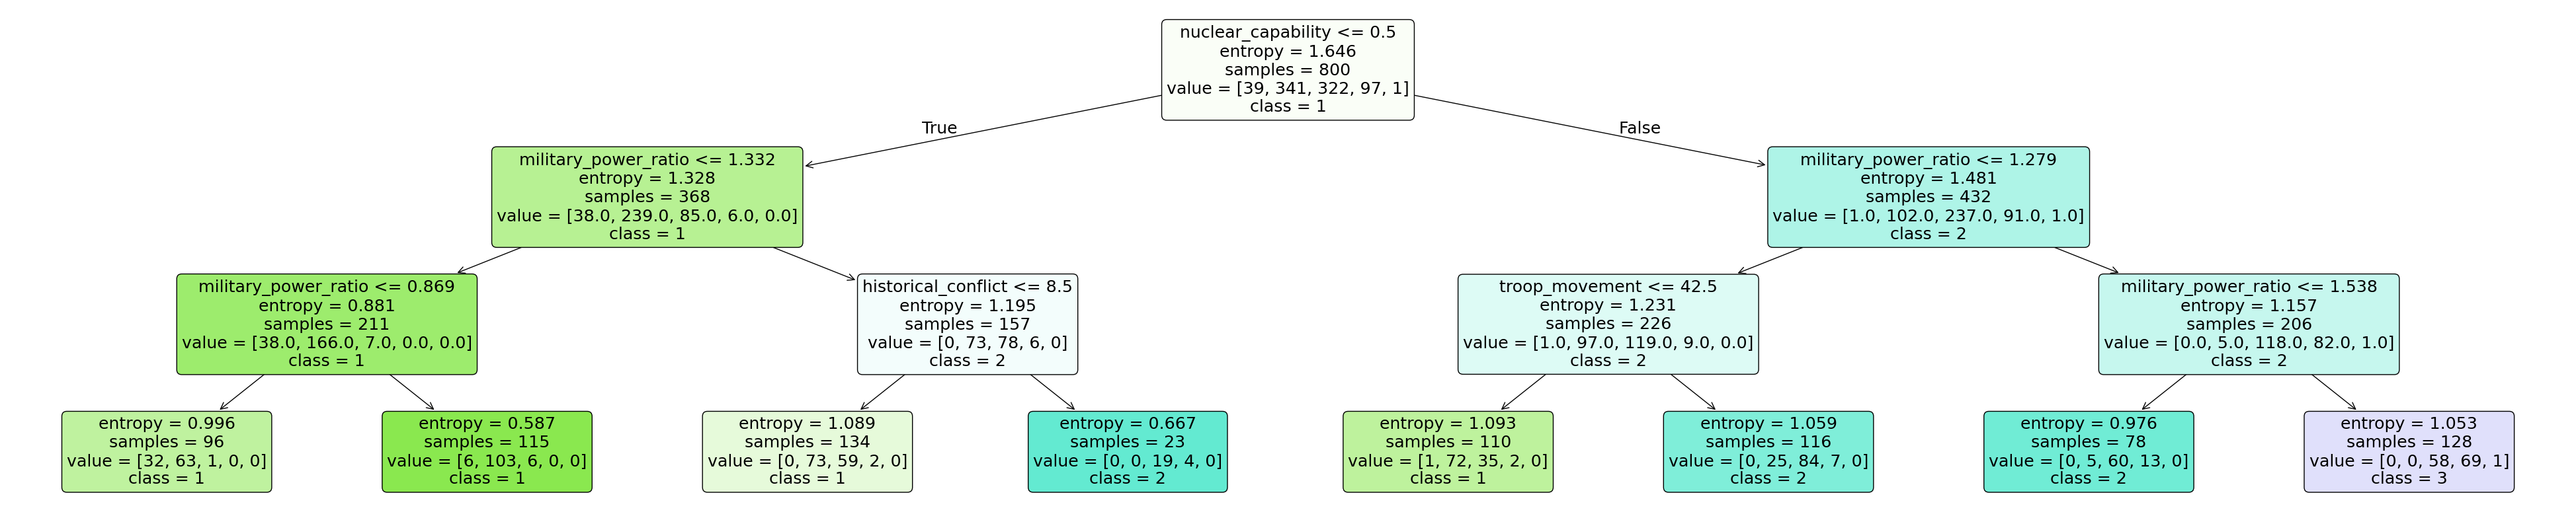

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(50,10))

plot_tree(
    cf,
    feature_names=features,
    class_names=["0","1","2","3","4"],
    filled=True,
    rounded=True
)

plt.show()


In [25]:
from sklearn import tree
text_representation = tree.export_text(
    cf,
    feature_names=features
)
print(text_representation)


|--- nuclear_capability <= 0.50
|   |--- military_power_ratio <= 1.33
|   |   |--- military_power_ratio <= 0.87
|   |   |   |--- class: 1
|   |   |--- military_power_ratio >  0.87
|   |   |   |--- class: 1
|   |--- military_power_ratio >  1.33
|   |   |--- historical_conflict <= 8.50
|   |   |   |--- class: 1
|   |   |--- historical_conflict >  8.50
|   |   |   |--- class: 2
|--- nuclear_capability >  0.50
|   |--- military_power_ratio <= 1.28
|   |   |--- troop_movement <= 42.50
|   |   |   |--- class: 1
|   |   |--- troop_movement >  42.50
|   |   |   |--- class: 2
|   |--- military_power_ratio >  1.28
|   |   |--- military_power_ratio <= 1.54
|   |   |   |--- class: 2
|   |   |--- military_power_ratio >  1.54
|   |   |   |--- class: 3



# Random Forest Classifier

In [26]:
from sklearn.ensemble import RandomForestClassifier


In [27]:
start_rf = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100,max_depth=3)
rf.fit(X_train,y_train)
end_rf = time.perf_counter()

rf_pred = rf.predict(X_test)
print("Random Forest: ", 100 * accuracy_score(y_test,rf_pred), "%")
print("Time take to train: ",end_rf-start_rf)


Random Forest:  63.0 %
Time take to train:  0.1094253999999637


# XGB Classifier

In [28]:
from xgboost import XGBClassifier


In [ ]:
start_time_xgb = time.perf_counter()
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate = 0.1,
    eval_metric = 'mlogloss'
)
xgb.fit(X_train,y_train)
end_time_xgb = time.perf_counter()
xgb_pred = xgb.predict(X_test)
print("XGBoost: ", 100 * accuracy_score(y_test,xgb_pred), "%")
print("Time taken to train: ", end_time_xgb-start_time_xgb)


XGBoost:  75.0 %
Time taken to train:  0.15026770000076795
